<a href="https://colab.research.google.com/github/Abyad-Raiyan/projects/blob/main/mock_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# Load Titanic dataset
# You can download from Kaggle or use seaborn's built-in dataset
titanic = sns.load_dataset('titanic')
print("Dataset shape:", titanic.shape)
print("\nFirst few rows:")
print(titanic.head())
print("\nDataset info:")
print(titanic.info())

Dataset shape: (891, 15)

First few rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------   

In [3]:
# Check missing values
print("Missing values:")
print(titanic.isnull().sum())

# Handle missing values
# Fill age with median
titanic['age'].fillna(titanic['age'].median(), inplace=True)

# Fill embarked with mode
titanic['embarked'].fillna(titanic['embarked'].mode()[0], inplace=True)

# Drop deck column (too many missing values)
titanic.drop('deck', axis=1, inplace=True)

# Drop duplicates if any
titanic.drop_duplicates(inplace=True)

# Encode categorical variables
# Convert sex to numeric
le_sex = LabelEncoder()
titanic['sex'] = le_sex.fit_transform(titanic['sex'])

# One-hot encode embarked and class
titanic = pd.get_dummies(titanic, columns=['embarked', 'class', 'who', 'adult_male'], drop_first=True)

# Drop unnecessary columns
columns_to_drop = ['alive', 'embark_town', 'alone']
titanic.drop(columns=[col for col in columns_to_drop if col in titanic.columns], inplace=True)

print("\nProcessed dataset shape:", titanic.shape)
print("\nColumns:", titanic.columns.tolist())

Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Processed dataset shape: (775, 14)

Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S', 'class_Second', 'class_Third', 'who_man', 'who_woman', 'adult_male_True']


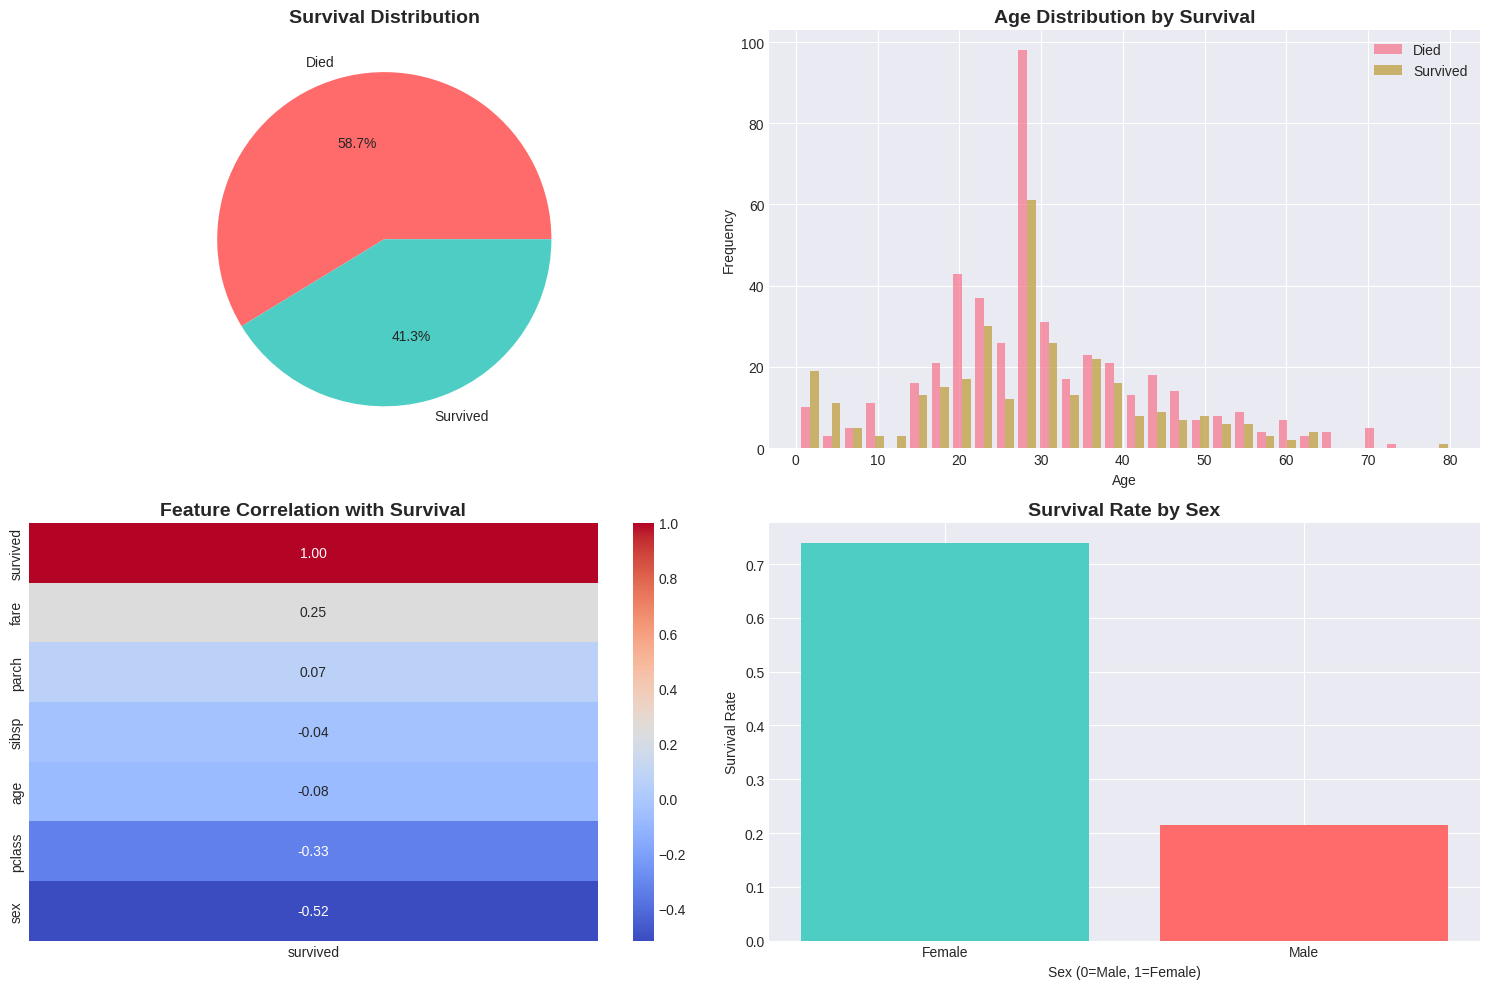

In [4]:
# Create subplots for visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Class Distribution
axes[0, 0].pie(titanic['survived'].value_counts(), labels=['Died', 'Survived'],
               autopct='%1.1f%%', colors=['#ff6b6b', '#4ecdc4'])
axes[0, 0].set_title('Survival Distribution', fontsize=14, fontweight='bold')

# 2. Age Distribution by Survival
axes[0, 1].hist([titanic[titanic['survived']==0]['age'],
                 titanic[titanic['survived']==1]['age']],
                label=['Died', 'Survived'], bins=30, alpha=0.7)
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Age Distribution by Survival', fontsize=14, fontweight='bold')
axes[0, 1].legend()

# 3. Correlation Heatmap
numeric_cols = titanic.select_dtypes(include=[np.number]).columns
correlation = titanic[numeric_cols].corr()
sns.heatmap(correlation[['survived']].sort_values(by='survived', ascending=False),
            annot=True, cmap='coolwarm', ax=axes[1, 0], fmt='.2f')
axes[1, 0].set_title('Feature Correlation with Survival', fontsize=14, fontweight='bold')

# 4. Sex vs Survival
survival_by_sex = titanic.groupby('sex')['survived'].mean()
axes[1, 1].bar(['Female', 'Male'], survival_by_sex.values, color=['#4ecdc4', '#ff6b6b'])
axes[1, 1].set_xlabel('Sex (0=Male, 1=Female)')
axes[1, 1].set_ylabel('Survival Rate')
axes[1, 1].set_title('Survival Rate by Sex', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
# Prepare features and target
# Remove target column from features
X = titanic.drop('survived', axis=1)
y = titanic['survived']

# Handle any remaining non-numeric columns
X = pd.get_dummies(X, drop_first=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: (620, 13)
Test set size: (155, 13)


In [6]:
# Model 1: Logistic Regression
print("="*50)
print("LOGISTIC REGRESSION")
print("="*50)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)

# Evaluation
lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"Accuracy: {lr_accuracy:.4f}")

# Confusion Matrix
lr_cm = confusion_matrix(y_test, lr_pred)
print("\nConfusion Matrix:")
print(lr_cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# Model 2: Random Forest
print("\n" + "="*50)
print("RANDOM FOREST")
print("="*50)

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)  # Random Forest doesn't require scaling

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Accuracy: {rf_accuracy:.4f}")

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_pred)
print("\nConfusion Matrix:")
print(rf_cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

LOGISTIC REGRESSION
Accuracy: 0.7935

Confusion Matrix:
[[77 14]
 [18 46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        91
           1       0.77      0.72      0.74        64

    accuracy                           0.79       155
   macro avg       0.79      0.78      0.78       155
weighted avg       0.79      0.79      0.79       155


RANDOM FOREST
Accuracy: 0.8258

Confusion Matrix:
[[80 11]
 [16 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86        91
           1       0.81      0.75      0.78        64

    accuracy                           0.83       155
   macro avg       0.82      0.81      0.82       155
weighted avg       0.83      0.83      0.82       155



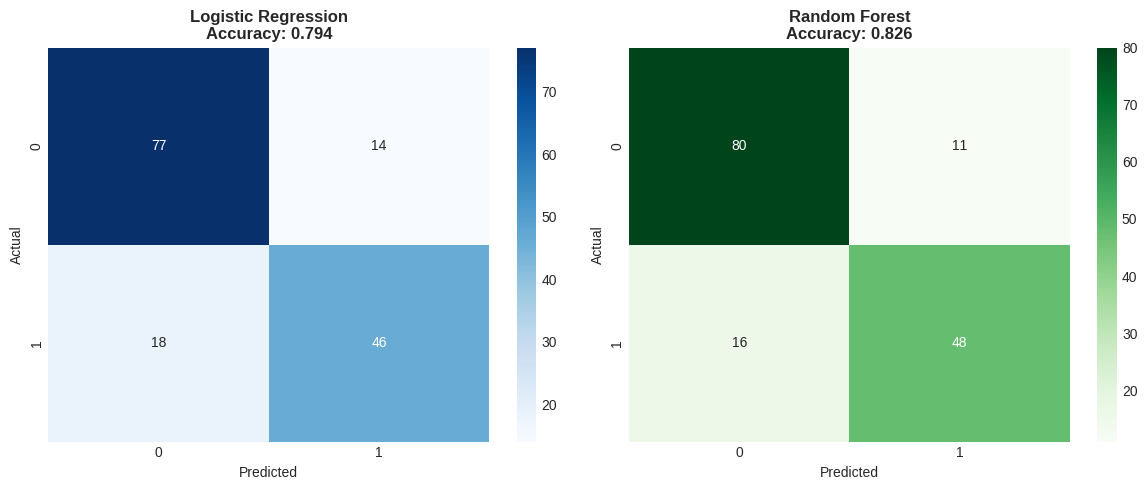

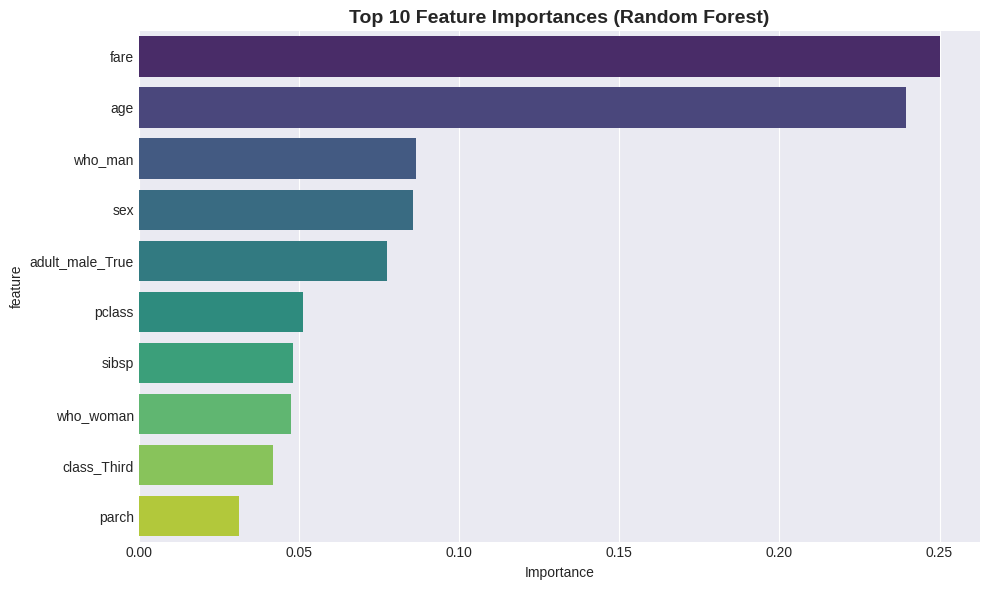

In [9]:
# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Logistic Regression\nAccuracy: {lr_accuracy:.3f}', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest Confusion Matrix
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Random Forest\nAccuracy: {rf_accuracy:.3f}', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Feature Importance (Random Forest)
if hasattr(rf_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
    plt.title('Top 10 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()